# 02 Modeling
## 모델링

여러 모델의 OOF score를 결합해 최종 review ranking score를 만든다.


## Setup
### 설정


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
SAMPLE_DIR = PROJECT_ROOT / "data" / "sample"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

def read_table(name):
    return pd.read_csv(TABLE_DIR / name)

def save_figure(name):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    return path

def pct(series, digits=2):
    return (series.astype(float) * 100).round(digits)


## Model candidates
### 모델 후보


In [2]:
model_candidates = pd.DataFrame(
    [
        {"family": "LightGBM", "representation": "full aggregate features", "role": "main tree baseline"},
        {"family": "XGBoost", "representation": "full aggregate features", "role": "tree diversity"},
        {"family": "CatBoost", "representation": "full aggregate features", "role": "categorical/tree diversity"},
        {"family": "LightGBM Top-N", "representation": "top feature subsets", "role": "feature-count robustness"},
        {"family": "Recent-change LightGBM", "representation": "recent/change features", "role": "behavior shift signal"},
        {"family": "Tabular MLP", "representation": "scaled numeric features", "role": "non-tree model diversity"},
        {"family": "Ridge meta model", "representation": "OOF predictions", "role": "blend calibration check"},
        {"family": "Equal blend", "representation": "8-model OOF scores", "role": "final ranking score"},
    ]
)
display(model_candidates)


,family,representation,role
0,LightGBM,full aggregate features,main tree baseline
1,XGBoost,full aggregate features,tree diversity
2,CatBoost,full aggregate features,categorical/tree diversity
3,LightGBM Top-N,top feature subsets,feature-count robustness
4,Recent-change LightGBM,recent/change features,behavior shift signal
5,Tabular MLP,scaled numeric features,non-tree model diversity
6,Ridge meta model,OOF predictions,blend calibration check
7,Equal blend,8-model OOF scores,final ranking score


## Final score table
### 최종 점수 테이블


In [3]:
score_sample = pd.read_csv(SAMPLE_DIR / "public_sample_scores.csv")
score_columns = pd.DataFrame(
    {
        "column": score_sample.columns,
        "non_null": [score_sample[col].notna().sum() for col in score_sample.columns],
        "dtype": [str(score_sample[col].dtype) for col in score_sample.columns],
    }
)
display(score_columns)
display(score_sample.head(10))


,column,non_null,dtype
0,masked_customer_id,1000,object
1,y_true,1000,int64
2,risk_score,1000,float64
3,risk_rank,1000,int64
4,risk_percentile,1000,float64
5,risk_band,1000,object
6,review_priority,1000,int64
7,action_candidate,1000,object
8,score_month,1000,object
9,model_version,1000,object


,masked_customer_id,y_true,risk_score,risk_rank,risk_percentile,risk_band,review_priority,action_candidate,score_month,model_version,policy_version
0,0f75afc8...,1,0.999092,1,0.000218,Critical,1,Urgent manual review candidate,2018-03-31,best_equal_8models,policy_v1
1,3c1d5685...,1,0.999003,2,0.000436,Critical,1,Urgent manual review candidate,2018-03-31,best_equal_8models,policy_v1
2,1ea68239...,1,0.999000,3,0.000654,Critical,1,Urgent manual review candidate,2018-03-31,best_equal_8models,policy_v1
3,c5c6a560...,1,0.998997,4,0.000872,Critical,1,Urgent manual review candidate,2018-03-31,best_equal_8models,policy_v1
4,08233ac9...,1,0.998996,5,0.001090,Critical,1,Urgent manual review candidate,2018-03-31,best_equal_8models,policy_v1
5,84aedebe...,1,0.998995,6,0.001307,Critical,1,Urgent manual review candidate,2018-03-31,best_equal_8models,policy_v1
6,740642b7...,1,0.998995,7,0.001525,Critical,1,Urgent manual review candidate,2018-03-31,best_equal_8models,policy_v1
7,25e4f99c...,1,0.998988,8,0.001743,Critical,1,Urgent manual review candidate,2018-03-31,best_equal_8models,policy_v1
8,93753f53...,1,0.998980,9,0.001961,Critical,1,Urgent manual review candidate,2018-03-31,best_equal_8models,policy_v1
9,a825ae8a...,1,0.998979,10,0.002179,Critical,1,Urgent manual review candidate,2018-03-31,best_equal_8models,policy_v1


## Score distribution
### 점수 분포


,risk_score
count,1000.000000
mean,0.998541
std,0.000191
min,0.998253
1%,0.998257
5%,0.998275
10%,0.998301
50%,0.998518
90%,0.998821
95%,0.998881


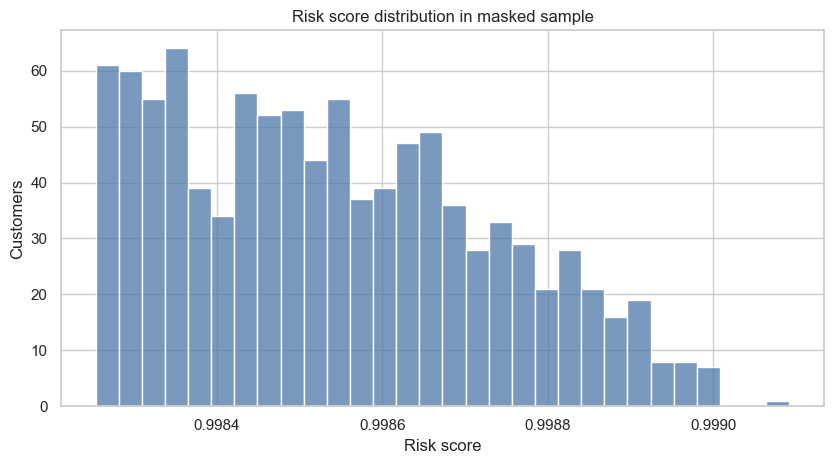

C:\Users\박동하\Documents\Codex\2026-05-16\files-mentioned-by-the-user-untitled48\amex-credit-risk-decisioning\outputs\figures\modeling_score_distribution.png


In [4]:
score_summary = score_sample["risk_score"].describe(percentiles=[0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]).to_frame("risk_score")
display(score_summary)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.histplot(score_sample["risk_score"], bins=30, color="#4C78A8", ax=ax)
ax.set_title("Risk score distribution in masked sample")
ax.set_xlabel("Risk score")
ax.set_ylabel("Customers")
path = save_figure("modeling_score_distribution.png")
plt.show()
print(path)


## Review ranking
### 리뷰 우선순위


In [5]:
ranking_check = score_sample.sort_values("risk_rank").head(20)
display(ranking_check[["masked_customer_id", "y_true", "risk_score", "risk_rank", "risk_percentile", "risk_band", "action_candidate"]])

band_counts = (
    score_sample.groupby("risk_band", as_index=False)
    .agg(customers=("masked_customer_id", "count"), avg_score=("risk_score", "mean"), defaults=("y_true", "sum"))
    .sort_values("avg_score", ascending=False)
)
band_counts["default_rate_pct"] = (band_counts["defaults"] / band_counts["customers"] * 100).round(2)
display(band_counts)


,masked_customer_id,y_true,risk_score,risk_rank,risk_percentile,risk_band,action_candidate
0,0f75afc8...,1,0.999092,1,0.000218,Critical,Urgent manual review candidate
1,3c1d5685...,1,0.999003,2,0.000436,Critical,Urgent manual review candidate
2,1ea68239...,1,0.999000,3,0.000654,Critical,Urgent manual review candidate
3,c5c6a560...,1,0.998997,4,0.000872,Critical,Urgent manual review candidate
4,08233ac9...,1,0.998996,5,0.001090,Critical,Urgent manual review candidate
5,84aedebe...,1,0.998995,6,0.001307,Critical,Urgent manual review candidate
6,740642b7...,1,0.998995,7,0.001525,Critical,Urgent manual review candidate
7,25e4f99c...,1,0.998988,8,0.001743,Critical,Urgent manual review candidate
8,93753f53...,1,0.998980,9,0.001961,Critical,Urgent manual review candidate
9,a825ae8a...,1,0.998979,10,0.002179,Critical,Urgent manual review candidate


,risk_band,customers,avg_score,defaults,default_rate_pct
0,Critical,1000,0.998541,1000,100.0


최종 모델 산출물은 확률값 자체가 아니라 risk score, risk rank, risk band다.
